# Using beamforming to localize oscillatory power modulations

The aim of this section is to localise modulations in oscillatory power using the Dynamical Imaging of Coherent Sources (DICS) method [1]. DICS is a beamforming technique based on spatial filtering in the frequency domain. For each grid point within the brain, a spatial filter is computed using the forward model in conjunction with the cross-spectral density (CSD) matrix. Spectral estimates are obtained via a multitaper approach. This method enables the estimation of power modulations at each grid point, which are subsequently mapped onto the individual structural MRIs. 


## Preparation

Import the relevant Python modules:

In [2]:
import os
import os.path as op
import numpy as np

import mne
from mne_bids import BIDSPath
from mne.cov import compute_covariance
from mne.beamformer import make_dics, apply_dics_csd
from mne.time_frequency import csd_multitaper

mne.viz.set_browser_backend("qt")  # or "matplotlib"

Using qt as 2D backend.


## File overview

This chapter relies on the following input files (embedded in the BIDS structure):

`<BIDS_ROOT>/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif` — the epoched data
`<BIDS_ROOT>/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_src.fif` — the source space
`<BIDS_ROOT>/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_fwd.fif` — the forward model
`<BIDS_ROOT>/derivatives/FreeSurfer` — the FreeSurfer reconstruction

Set the paths and names for the data below. Note that these will depend on your local setup.

## Defining files names and paths



In [3]:
subject = "01"
session = "01"
task = "SpAtt"  # name of the task
run = "01"
meg_suffix = "meg"
epo_suffix = "epo"
mri_suffix = "T1w"
bem_suffix = "bem-sol"
src_suffix = "src"
fwd_suffix = "fwd"

# data_path='C:/Users/rakshita/Documents/Cerca_raw_files'
data_path = "Sub_01/Data"


bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root = op.join(bids_root, "derivatives/analysis")

bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    run=run,
    suffix=epo_suffix,
    datatype="meg",
    root=deriv_root,
    extension=".fif",
    check=False,
)


fwd_fname = bids_path.basename.replace(epo_suffix, fwd_suffix)
fwd_file = op.join(bids_path.directory, fwd_fname)
src_file = fwd_file.replace(fwd_suffix, src_suffix)
bem_file = fwd_file.replace(fwd_suffix, bem_suffix)


fs_subject = "T1s"
fs_root = op.join(bids_root, "derivatives", "FreeSurfer")


## The forward model

We use the forward model computed in the previous chapter. It was constructed for the OPM sensors using the volumetric source space (not the cortical-surface solution). The forward model contains all OPM channels; as in the earlier chapters, we will restrict the source analysis to the radial (Z-axis) channels, so `make_dics` below will use only those channels that are common to the epochs and the forward model.

In [4]:
fwd = mne.read_forward_solution(fwd_file)

Reading forward solution from /Users/harrisonritz/repos/cerca-flux-tutorial/Sub_01/Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (9786 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame



## Reading the trials

Now read the trials (epochs) for all trial types:


In [5]:
epochs = mne.read_epochs(bids_path.fpath, proj=False)

Reading /Users/harrisonritz/repos/cerca-flux-tutorial/Sub_01/Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif ...
    Read a total of 8 projection items:
        HFC: l=1 m=0 (1 x 180) active
        HFC: l=2 m=0 (1 x 180) active
        HFC: l=1 m=-1 (1 x 180) active
        HFC: l=1 m=1 (1 x 180) active
        HFC: l=2 m=-1 (1 x 180) active
        HFC: l=2 m=1 (1 x 180) active
        HFC: l=2 m=-2 (1 x 180) active
        HFC: l=2 m=2 (1 x 180) active
    Found the data of interest:
        t =    -749.33 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
326 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 8)


We will subsequently focus on activity in the Z-axis sensors:

In [6]:
OPMZ = [
    item
    for item in epochs.info["ch_names"]
    if item.endswith("Z") and not item.startswith("BNC")
]
epochs = epochs.copy().pick(OPMZ)

As a subselection of sensors were done, the projection must be re-normalized:

In [7]:
epochs.info.normalize_proj()


## Source modeling of modulations of alpha band activity
### Calculating the cross-spectral density matrices for the alpha band

The spatial filters in the DICS beamforming approach are computed from the forward model and the cross-spectral density (CSD) matrices. We focus on the −0.7 to −0.2 s interval before the cue onset and the 0.1 to 0.6 s interval after the cue onset (both ΔT = 0.5 s). During the cue–target interval the alpha-band activity is suppressed (see the *Time–Frequency Representations of Power* chapter).

We start by computing the CSDs for the 8–12 Hz alpha band, for each condition and for the pre- and post-cue intervals. With the multitaper method, a bandwidth of ΔF = 3 Hz on a ΔT = 0.5 s window yields a single DPSS taper.

In [8]:
print("Baseline Interval")
csd_aleft_pre = csd_multitaper(
    epochs["cue_Left"],
    fmin=8,
    fmax=12,
    tmin=-0.7,
    tmax=-0.2,
    bandwidth=3,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)
csd_aright_pre = csd_multitaper(
    epochs["cue_Right"],
    fmin=8,
    fmax=12,
    tmin=-0.7,
    tmax=-0.2,
    bandwidth=3,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)

print("Cue Interval")
csd_aleft_cue = csd_multitaper(
    epochs["cue_Left"],
    fmin=8,
    fmax=12,
    tmin=0.1,
    tmax=0.6,
    bandwidth=3,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)
csd_aright_cue = csd_multitaper(
    epochs["cue_Right"],
    fmin=8,
    fmax=12,
    tmin=0.1,
    tmax=0.6,
    bandwidth=3,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)

Baseline Interval


/var/folders/nl/tj__js1s2l7dkdwd16gh1xsc0000gn/T/ipykernel_28709/2932111431.py:2: RuntimeWarning: joblib not installed. Cannot run in parallel.
  csd_aleft_pre = csd_multitaper(
/var/folders/nl/tj__js1s2l7dkdwd16gh1xsc0000gn/T/ipykernel_28709/2932111431.py:13: RuntimeWarning: joblib not installed. Cannot run in parallel.
  csd_aright_pre = csd_multitaper(
/var/folders/nl/tj__js1s2l7dkdwd16gh1xsc0000gn/T/ipykernel_28709/2932111431.py:26: RuntimeWarning: joblib not installed. Cannot run in parallel.
  csd_aleft_cue = csd_multitaper(


Cue Interval


/var/folders/nl/tj__js1s2l7dkdwd16gh1xsc0000gn/T/ipykernel_28709/2932111431.py:37: RuntimeWarning: joblib not installed. Cannot run in parallel.
  csd_aright_cue = csd_multitaper(


The spatial filters must be based on the covariance matrices combined ('common spatial filter'). Therefore the CSDs are averaged:

In [9]:
csd_acommon1 = csd_aleft_cue.copy()
csd_acommon1._data = (
    csd_aleft_cue._data
    + csd_aright_cue._data
    + csd_aleft_pre._data
    + csd_aright_pre._data
) / 4

**Question 1** A single *common* spatial filter is computed from the CSD combined across conditions and intervals, and then applied to each condition/interval separately. Why is a common filter used rather than a separate filter per condition, and what bias could per-condition filters introduce when the conditions are later contrasted?

To compute the spatial filters we also need the rank of the CSD, which is similar to the rank of the covariance matrix:

In [10]:
rank = mne.compute_rank(epochs, tol=1e-5, tol_kind="relative", proj=True)
print(rank)

Computing rank from data with rank=None
    Estimated rank (mag): 52
    MAG: rank 52 computed from 60 data channels with 8 projectors
{'mag': 52}


Note that the rank is 52 even though there are 60 sensors. This rank deficiency is caused by the HFC and ICA steps, and therefore requires regularization before the matrix is inverted in the beamformer computation.

**Question 2** The data rank (52) is lower than the number of sensors (60) because of the HFC and ICA steps. Why does rank deficiency require regularization before the beamformer inversion, and how does the 5% regularization trade off spatial resolution against noise sensitivity?

### Derive the spatial filters for the alpha band

Now compute the filters using the forward model `fwd` and the combined CSD matrix `csd_acommon1`. The filters are regularized by loading the diagonal of the CSD with 5% of the sensor power. For each source, the orientation is optimized to maximize the output power.

Since OPM data consist only of magnetometers, the issue of scale differences between sensor types does not apply. The depth bias is addressed by setting `depth=0` and, above all, by using relative comparisons across conditions or intervals. The `mean` in `csd_acommon1.mean()` averages the CSD over the selected frequency range.

Given that the CSD matrices may still be (mildly) rank-deficient, MNE-Python computes a truncated pseudo-inverse using the effective rank. For a data matrix **X** of rank `k`, the truncated pseudo-inverse **X⁺** is obtained via the singular value decomposition:

**X = UΣVᵀ**,  
**X⁺ = VₖΣₖ⁻¹Uₖᵀ**,

where only the first `k` singular values of Σ and the first `k` columns of **U** and **V** are retained.

In [11]:
afilters1 = make_dics(
    epochs.info,
    fwd,
    csd_acommon1.mean(),
    noise_csd=None,
    reg=0.05,
    pick_ori="max-power",
    reduce_rank=True,
    real_filter=True,
    rank=rank,
    depth=0,
)

Identifying common channels ...
Dropped the following channels:
['F5 A6 Y', 'O2 H7 X', 'P5 E7 Y', 'O7 H5 Y', 'O3 G5 X', 'F4 B6 X', 'T1 C6 Y', 'T10 F3 Y', 'P6 F2 X', 'F6 B2 X', 'T5 C5 X', 'F5 A6 Z', 'Fpz A2 X', 'T9 G4 X', 'O8 H2 Y', 'F4 B6 Y', 'P10 D5 X', 'F7 A4 Y', 'O6 D3 Y', 'F1 A1 Y', 'C3 C4 Y', 'T14 H6 Y', 'C1 A7 X', 'O1 G2 X', 'T2 B7 Y', 'AFz A5 X', 'F1 A1 X', 'O8 H2 Z', 'F3 A3 Y', 'P1 C1 X', 'C8 D2 Y', 'T13 G6 Y', 'F10 B8 X', 'F8 B4 Z', 'C5 C2 Y', 'T14 H6 Z', 'C3 C4 X', 'T11 G8 X', 'C6 F1 Y', 'C2 F7 Y', 'P5 E7 X', 'T3 C3 X', 'C4 F5 Y', 'T4 B1 X', 'T5 C5 Y', 'F3 A3 X', 'P2 D4 X', 'T8 F4 Y', 'FCz E2 X', 'P2 D4 Y', 'Oz H4 Y', 'T6 F8 X', 'Cz D8 Y', 'C2 F7 X', 'T7 E5 X', 'P9 G1 Y', 'T7 E5 Y', 'Fz A8 Y', 'P8 D1 Y', 'F12 B5 X', 'P3 E3 X', 'F11 C7 Y', 'T12 F6 Y', 'T1 C6 X', 'T2 B7 X', 'Fpz A2 Y', 'P1 C1 Y', 'O2 H7 Y', 'O5 G3 X', 'P12 D7 X', 'P10 D5 Y', 'F11 C7 X', 'F9 C8 Y', 'C5 C2 X', 'F5 A6 X', 'P4 D6 X', 'O1 G2 Y', 'O4 H3 X', 'Fz A8 X', 'Iz H8 Y', 'P12 D7 Y', 'O4 H3 Y', 'C7 E4 X', 'C1 

In [12]:
stc_aleft_cue, freqs = apply_dics_csd(csd_aleft_cue.mean(), afilters1)
stc_aright_cue, freqs = apply_dics_csd(csd_aright_cue.mean(), afilters1)

stc_aleft_pre, freqs = apply_dics_csd(csd_aleft_pre.mean(), afilters1)
stc_aright_pre, freqs = apply_dics_csd(csd_aright_pre.mean(), afilters1)

Computing DICS source power...
[done]
Computing DICS source power...
[done]
Computing DICS source power...
[done]
Computing DICS source power...
[done]


Calculate the relative change in power — the change in alpha power between the intervals before and after cue onset. Note that we always compare intervals or conditions in order to reduce the depth bias:

In [13]:
# Relative change in alpha power: (post-cue − pre-cue) / pre-cue, averaged over left and right
stc_arel = ((stc_aleft_cue + stc_aright_cue) - (stc_aleft_pre + stc_aright_pre)) / (
    stc_aleft_pre + stc_aright_pre
)

**Question 3** All results are expressed as relative contrasts (e.g. (post−pre)/pre) rather than absolute power. Why does the beamformer output carry a depth bias, and how do such relative contrasts mitigate it?

### Plotting the alpha band modulation

Now plot the source results:

In [30]:
src = fwd["src"]
print(src)

%matplotlib qt
stc_arel.plot(
    src=src, subject=fs_subject, subjects_dir=fs_root, mode="stat_map", verbose=True
);

<SourceSpaces: [<volume, shape=(np.int32(30), np.int32(34), np.int32(30)), n_used=9786>] head coords, subject 'T1s', ~72.3 MiB>
Showing: t = 0.000 s, (-34.0, -26.4, 65.2) mm, [8, 12, 25] vox, 25868 vertex
Using control points [0.24140358 0.25704942 0.44146484]


Note the strong alpha depression in visual areas.

### Calculating the modulation in alpha power with attention

This is done for the cue–target interval, contrasting attention right minus left. The first step is to construct a cross-spectral density matrix for the cue–target interval, combined across the left and right conditions:

In [31]:
csd_acommon2 = csd_aleft_cue.copy()
csd_acommon2._data = (csd_aleft_cue._data + csd_aright_cue._data) / 2

subsequently the respective filter is estimated:

In [32]:
afilters2 = make_dics(
    epochs.info,
    fwd,
    csd_acommon2.mean(),
    noise_csd=None,
    reg=0.05,
    pick_ori="max-power",
    reduce_rank=True,
    real_filter=True,
    rank=rank,
    depth=0,
)

Identifying common channels ...
Dropped the following channels:
['F5 A6 Y', 'O2 H7 X', 'P5 E7 Y', 'O7 H5 Y', 'O3 G5 X', 'F4 B6 X', 'T1 C6 Y', 'T10 F3 Y', 'P6 F2 X', 'F6 B2 X', 'T5 C5 X', 'F5 A6 Z', 'Fpz A2 X', 'T9 G4 X', 'O8 H2 Y', 'F4 B6 Y', 'P10 D5 X', 'F7 A4 Y', 'O6 D3 Y', 'F1 A1 Y', 'C3 C4 Y', 'T14 H6 Y', 'C1 A7 X', 'O1 G2 X', 'T2 B7 Y', 'AFz A5 X', 'F1 A1 X', 'O8 H2 Z', 'F3 A3 Y', 'P1 C1 X', 'C8 D2 Y', 'T13 G6 Y', 'F10 B8 X', 'F8 B4 Z', 'C5 C2 Y', 'T14 H6 Z', 'C3 C4 X', 'T11 G8 X', 'C6 F1 Y', 'C2 F7 Y', 'P5 E7 X', 'T3 C3 X', 'C4 F5 Y', 'T4 B1 X', 'T5 C5 Y', 'F3 A3 X', 'P2 D4 X', 'T8 F4 Y', 'FCz E2 X', 'P2 D4 Y', 'Oz H4 Y', 'T6 F8 X', 'Cz D8 Y', 'C2 F7 X', 'T7 E5 X', 'P9 G1 Y', 'T7 E5 Y', 'Fz A8 Y', 'P8 D1 Y', 'F12 B5 X', 'P3 E3 X', 'F11 C7 Y', 'T12 F6 Y', 'T1 C6 X', 'T2 B7 X', 'Fpz A2 Y', 'P1 C1 Y', 'O2 H7 Y', 'O5 G3 X', 'P12 D7 X', 'P10 D5 Y', 'F11 C7 X', 'F9 C8 Y', 'C5 C2 X', 'F5 A6 X', 'P4 D6 X', 'O1 G2 Y', 'O4 H3 X', 'Fz A8 X', 'Iz H8 Y', 'P12 D7 Y', 'O4 H3 Y', 'C7 E4 X', 'C1 

Then apply the filter for the left and right attention conditions

In [33]:
stc_aleft_cue, freqs = apply_dics_csd(csd_aleft_cue.mean(), afilters2)
stc_aright_cue, freqs = apply_dics_csd(csd_aright_cue.mean(), afilters2)

Computing DICS source power...
[done]
Computing DICS source power...
[done]


Finally calculate the relative attend left verus right contrasts:

In [34]:
# Alpha lateralisation: (attend right − attend left) / (attend right + attend left)
stc_aRvsL = (stc_aright_cue - stc_aleft_cue) / (stc_aright_cue + stc_aleft_cue)

In [36]:
%matplotlib qt
stc_aRvsL.plot(src=src, subject=fs_subject, subjects_dir=fs_root);

Showing: t = 0.000 s, (-24.0, 53.6, 55.2) mm, [10, 28, 23] vox, 24310 vertex
Using control points [0.08144899 0.09246663 0.15708174]


/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/ipykernel/eventloops.py:158: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  el.exec() if hasattr(el, "exec") else el.exec_()


The sources in the right posterior areas reflect the relative increase in alpha. This is due to allocation to the right hemifield resulting in a relative alpha power increase in the right hemisphere.


## Source modeling of modulations of gamma band activity

We next localise the sources associated with the modulation in the 70–80 Hz gamma band. Here we use the multitaper approach with more spectral smoothing, which suits the broad-band gamma response.

As a first step we compute the CSD for the baseline, cue, and stimulus intervals, and for all conditions. The bandwidth is ΔF = 8 Hz on a ΔT = 0.5 s window, which yields 3 tapers.

**Question 4** The alpha analysis uses a 3 Hz bandwidth (1 taper) whereas the gamma analysis uses an 8 Hz bandwidth (3 tapers). Explain why more spectral smoothing (more tapers) is appropriate for gamma but not for alpha.

In [21]:
print("Pre")
csd_gleft_pre = csd_multitaper(
    epochs["cue_Left"],
    fmin=70,
    fmax=80,
    tmin=-0.7,
    tmax=-0.2,
    bandwidth=8,
    adaptive=True,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)
csd_gright_pre = csd_multitaper(
    epochs["cue_Right"],
    fmin=70,
    fmax=80,
    tmin=-0.7,
    tmax=-0.2,
    bandwidth=8,
    adaptive=True,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)

print("Cue")
csd_gleft_cue = csd_multitaper(
    epochs["cue_Left"],
    fmin=70,
    fmax=80,
    tmin=0.6,
    tmax=1.1,
    bandwidth=8,
    adaptive=True,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)
csd_gright_cue = csd_multitaper(
    epochs["cue_Right"],
    fmin=70,
    fmax=80,
    tmin=0.6,
    tmax=1.1,
    bandwidth=8,
    adaptive=True,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)

print("Stim")
csd_gleft_act = csd_multitaper(
    epochs["cue_Left"],
    fmin=70,
    fmax=80,
    tmin=1.2,
    tmax=1.7,
    bandwidth=8,
    adaptive=True,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)
csd_gright_act = csd_multitaper(
    epochs["cue_Right"],
    fmin=70,
    fmax=80,
    tmin=1.2,
    tmax=1.7,
    bandwidth=8,
    adaptive=True,
    low_bias=True,
    verbose=False,
    n_jobs=-1,
)

Pre
Cue
Stim


In [22]:
csd_gcommon = csd_gleft_pre.copy()
csd_gcommon._data = (
    csd_gleft_cue._data
    + csd_gright_cue._data
    + csd_gleft_act._data
    + csd_gright_act._data
) / 4


### Derive the spatial filters for the gamma band

The filters will be calculated on the basis of the common CSD. The rank estimate based on the covariance matrix will be used. The deduced rank is due to the HFC as well as the ICA.


In [23]:
gfilters = make_dics(
    epochs.info,
    fwd,
    csd_gcommon.mean(),
    noise_csd=None,
    reg=0.05,
    pick_ori="max-power",
    reduce_rank=True,
    real_filter=True,
    rank=rank,
    depth=0,
)

Identifying common channels ...
Dropped the following channels:
['F5 A6 Y', 'O2 H7 X', 'P5 E7 Y', 'O7 H5 Y', 'O3 G5 X', 'F4 B6 X', 'T1 C6 Y', 'T10 F3 Y', 'P6 F2 X', 'F6 B2 X', 'T5 C5 X', 'F5 A6 Z', 'Fpz A2 X', 'T9 G4 X', 'O8 H2 Y', 'F4 B6 Y', 'P10 D5 X', 'F7 A4 Y', 'O6 D3 Y', 'F1 A1 Y', 'C3 C4 Y', 'T14 H6 Y', 'C1 A7 X', 'O1 G2 X', 'T2 B7 Y', 'AFz A5 X', 'F1 A1 X', 'O8 H2 Z', 'F3 A3 Y', 'P1 C1 X', 'C8 D2 Y', 'T13 G6 Y', 'F10 B8 X', 'F8 B4 Z', 'C5 C2 Y', 'T14 H6 Z', 'C3 C4 X', 'T11 G8 X', 'C6 F1 Y', 'C2 F7 Y', 'P5 E7 X', 'T3 C3 X', 'C4 F5 Y', 'T4 B1 X', 'T5 C5 Y', 'F3 A3 X', 'P2 D4 X', 'T8 F4 Y', 'FCz E2 X', 'P2 D4 Y', 'Oz H4 Y', 'T6 F8 X', 'Cz D8 Y', 'C2 F7 X', 'T7 E5 X', 'P9 G1 Y', 'T7 E5 Y', 'Fz A8 Y', 'P8 D1 Y', 'F12 B5 X', 'P3 E3 X', 'F11 C7 Y', 'T12 F6 Y', 'T1 C6 X', 'T2 B7 X', 'Fpz A2 Y', 'P1 C1 Y', 'O2 H7 Y', 'O5 G3 X', 'P12 D7 X', 'P10 D5 Y', 'F11 C7 X', 'F9 C8 Y', 'C5 C2 X', 'F5 A6 X', 'P4 D6 X', 'O1 G2 Y', 'O4 H3 X', 'Fz A8 X', 'Iz H8 Y', 'P12 D7 Y', 'O4 H3 Y', 'C7 E4 X', 'C1 

### Apply the filters and plot the gamma modulation

The filters are then applied:


In [24]:
stc_gleft_cue, freqs = apply_dics_csd(csd_gleft_cue.mean(), gfilters)
stc_gleft_act, freqs = apply_dics_csd(csd_gleft_act.mean(), gfilters)
stc_gright_cue, freqs = apply_dics_csd(csd_gright_cue.mean(), gfilters)
stc_gright_act, freqs = apply_dics_csd(csd_gright_act.mean(), gfilters)

Computing DICS source power...
[done]
Computing DICS source power...
[done]
Computing DICS source power...
[done]
Computing DICS source power...
[done]


Now calculate the relative modulation in gamma power with respect to the baseline:

In [25]:
stc_grel = ((stc_gleft_act + stc_gright_act) - (stc_gleft_cue + stc_gright_cue)) / (
    stc_gleft_cue + stc_gright_cue
)

and plot the relative modulation in the interactive plot. Click on the visual cortex and note the increase in gamma power.

Fixing initial position: [-3000.0, -9000.0, 0.0] mm
Showing: t = 0.000 s, (-24.0, -76.4, 0.2) mm, [10, 2, 12] vox, 12310 vertex


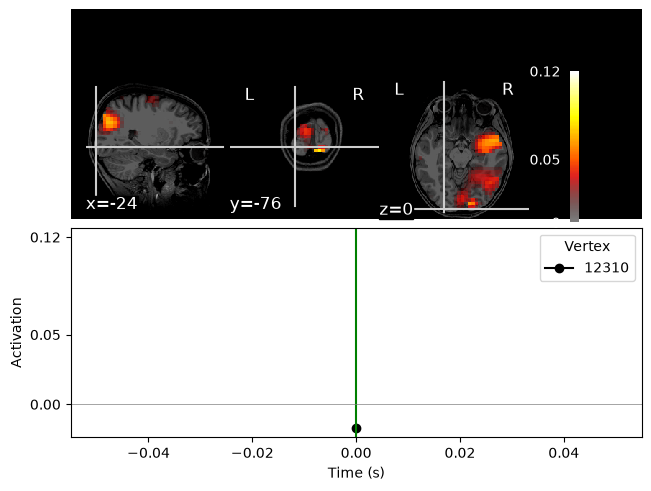

In [26]:
src = fwd["src"]
%matplotlib inline

brain = stc_grel.plot(
    src=src,
    subject=fs_subject,
    subjects_dir=fs_root,
    mode="stat_map",
    initial_pos=[-3, -9, 0],
    clim=dict(kind="value", lims=[0, 0.05, 0.12]),
);

Note the sources of gamma activity in early visual cortex. 

## Preregistration and publication

A preregistration should specify the beamforming pipeline in enough detail to reproduce it exactly. The spectral estimation, the time/frequency windows, the common filter, the regularization, and the contrasts all shape the source estimate, so these choices should be fixed in advance. We recommend committing to the following:

**Spectral estimation (CSD)**
- The method (multitaper, DPSS tapers) and the frequency bands (here 8–12 Hz alpha; 70–80 Hz gamma).
- The spectral bandwidth and resulting number of tapers per band (here 3 Hz → 1 taper for alpha; 8 Hz → 3 tapers for gamma) and the window length (ΔT = 0.5 s).
- The time windows contrasted (alpha: −0.7 to −0.2 s vs 0.1 to 0.6 s around the cue; gamma: pre- vs post-grating intervals).

**Beamformer**
- The forward model and source space (volumetric, from the forward-model chapter) and the sensors used (radial Z-axis OPM channels).
- The common spatial filter (formed from the CSD combined across conditions and intervals), the regularization (here 5%), the orientation choice (`pick_ori='max-power'`), the rank handling, and `depth=0`.
- That contrasts are expressed as relative changes (e.g. (post−pre)/pre, (right−left)/(right+left)) to mitigate the depth bias.

**General**
- Software and versions (MNE-Python, MNE-BIDS, FreeSurfer).
- How the source estimates are mapped to the individual MRI and, for group analysis, to a template.

**Example methods text**

> "Dynamic Imaging of Coherent Sources (DICS) [1] was used to localise modulations in oscillatory power. Cross-spectral density (CSD) matrices were computed with a multitaper method: for the alpha band (8–12 Hz) a 3 Hz bandwidth was used (1 DPSS taper), and for the gamma band (70–80 Hz) an 8 Hz bandwidth (3 DPSS tapers), each on 0.5 s windows. For alpha, CSDs were computed for a pre-cue (−0.7 to −0.2 s) and a post-cue (0.1 to 0.6 s) interval; for gamma, for pre- and post-grating intervals. A common spatial filter was formed from the CSDs combined across conditions and intervals, using the forward model from the volumetric source space, with source orientations optimised for maximum power, 5% regularisation, and the data rank estimated from the covariance matrix. The filters were applied to the condition- and interval-specific CSDs, and power modulations were expressed as relative changes and mapped onto each participant's structural MRI. Analyses were performed in MNE-Python [4,5]."

## References

1. Gross, J., Kujala, J., Hämäläinen, M., Timmermann, L., Schnitzler, A., & Salmelin, R. (2001). Dynamic imaging of coherent sources: Studying neural interactions in the human brain. *Proceedings of the National Academy of Sciences of the United States of America*, **98**(2), 694–699. https://doi.org/10.1073/pnas.98.2.694

2. Engemann, D. A., & Gramfort, A. (2015). Automated model selection in covariance estimation and spatial whitening of MEG and EEG signals. *NeuroImage*, **108**, 328–342. https://doi.org/10.1016/j.neuroimage.2014.12.040

3. Sekihara, K., Hild, K. E., Dalal, S. S., & Nagarajan, S. S. (2008). Performance of prewhitening beamforming in MEG dual experimental conditions. *IEEE Transactions on Biomedical Engineering*, **55**(3), 1112–1121. https://doi.org/10.1109/TBME.2007.912427

4. van Vliet, M., Liljeström, M., Aro, S., Salmelin, R., & Kujala, J. (2018). Analysis of Functional Connectivity and Oscillatory Power Using DICS: From Raw MEG Data to Group-Level Statistics in Python. *Frontiers in Neuroscience*, **12**, 586. https://doi.org/10.3389/fnins.2018.00586

5. Westner, B. U., Dalal, S. S., Gramfort, A., Litvak, V., Mosher, J. C., Oostenveld, R., & Schoffelen, J. M. (2021). A unified view on beamformers for M/EEG source reconstruction. *NeuroImage*, **246**, 118789. https://doi.org/10.1016/j.neuroimage.2021.118789

6. Gramfort, A., Luessi, M., Larson, E., et al. (2013). MEG and EEG data analysis with MNE-Python. *Frontiers in Neuroscience*, **7**, 267. https://doi.org/10.3389/fnins.2013.00267